# Objectif
- **Objectif** : Prétraitement : Pré‑calculer toutes les représentations vectorielles du cours pour une recherche rapide ensuite. (cours JSON => numérique)
- **Entrée** : `data/2-json/cours.json`
- **Traitements** :
  - Charger le JSON.
  - Calculer les représentations numériques par 3 méthodes :
    - TF
    - TF‑IDF
    - Embeddings
- **Sorties** :
    - résultats de TF : vectoriseur et matrice TF
    - résultats de TF-IDF : vectoriseur et matrice TF-IDF
    - résultats de l'embeddings : embeddings et métadonnées.

# Chargement du cours

In [1]:
import json
import numpy as np
from pprint import pprint

# Chargement du cours
with open("../data/2-json/cours.json", "r", encoding="utf-8") as f:
    course = json.load(f)

# Agréger les slides de TOUS les chapitres
slides = []
for chap in course["chapters"]:
    for slide in chap["content"]:
        slide["chap_id"]   = chap["chap_id"]
        slide["chap_name"] = chap["chap_name"]
        slides.append(slide)

print(f"{len(course['chapters'])} chapitre(s) chargé(s).")
print(f"{len(slides)} slides au total.")
pprint(slides[0])


2 chapitre(s) chargé(s).
75 slides au total.
{'categories': {},
 'chap_id': 1,
 'chap_name': 'Représentation temporelle des signaux',
 'notions': ['Nombre', 'Continus', 'discrets'],
 'section': 'Les différentes classes de signaux',
 'slide_content': 'Différents critères de classification :\n'
                  'Nombre de variables ;\n'
                  'Signaux réels / complexes ;\n'
                  'Déterministes / aléatoires ;\n'
                  'Continus / discrets ;\n'
                  'Classification énergétique.',
 'slide_id': 2}


# Extraction des caractéristiques textuelles

L'objectif est de **représenter chaque slide sous forme numérique** afin de pouvoir mesurer dans une étape ultérieure la similarité entre une question posée par l'étudiant et le contenu du cours. On utilise pour cela 3 méthodes de transformation vectorielle/numérique :

## Fréquence des mots TF

### Implémentation
TF(Term Frequency) est une méthode de recherche d'information (Information Retrieval) qui consiste à attribuer à chaque terme(mot dans notre cas) une fréquence d'utilisation par rapport au document(le contenu d'un slide dans notre cas).  
La fréquence brute d'un terme $t$ dans un document $d$ est :

$$\text{TF}(t, d) = \frac{\text{nombre d'occurrences de } t \text{ dans } d}{\text{nombre total de mots dans } d}$$

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
import pandas as pd

# ── Corpus = tous les contenus des slides / document = un contneu d'un slide ──────────────────────────────────────────────────────────────
# Nettoyage défensif : on remplace None par chaîne vide
corpus = [
    (slide.get("slide_content") or "").lower().strip()
    for slide in slides
] # liste des contenus de slides

labels = [
    f"Slide {slide['slide_id']} – {slide['section']}"
    for slide in slides
]# liste de chaines indiquants l'id et le titre des slide

# Stop words français (les plus courants)
STOP_WORDS_FR = [
    "le","la","les","un","une","des","de","du","et","en","au","aux",
    "ce","se","sa","son","ses","leur","leurs","mon","ton","votre","notre",
    "que","qui","quoi","dont","où","mais","ou","car","ni","pour","par",
    "sur","sous","dans","avec","sans","entre","vers","si","est","sont",
    "être","avoir","fait","plus","comme","tout","bien","très","même","aussi",
    "on","il","elle","ils","elles","nous","vous","je","tu","y","en",
]

# ── Vectorisation TF ───────────────────────────────────────────────────────
tf_vectorizer = CountVectorizer(# Création d’un vectoriseur basé sur la fréquence des mots (Term Frequency)
    analyzer="word",           # Indique que l’analyse se fait au niveau des mots (et non des caractères)
    ngram_range=(1, 2),        # unigrammes + bigrammes
    min_df=2,                  # ignorer les termes trop rares
    max_df=0.85,               # ignorer les termes omniprésents
    strip_accents="unicode",   # Supprime les accents (é → e, à → a, etc.) pour uniformiser le texte
    stop_words=STOP_WORDS_FR,  # stop words français
    token_pattern=r"\b[a-zA-ZÀ-ÿ]{2,}\b"  # garde lettres accentuées
)

# Matrice de comptes bruts
# Apprend le vocabulaire à partir du corpus + transforme les documents en matrice de comptage
# Résultat : une matrice de taille (nb_documents, taille_vocabulaire)
tf_counts = tf_vectorizer.fit_transform(corpus)

# Normalisation L1 → fréquences relatives (TF au sens strict)
tf_matrix = normalize(tf_counts, norm="l1")

# Vocabulaire
# Récupère la liste des mots (features) du vocabulaire appris
# Chaque mot correspond à une colonne de la matrice tf_matrix
vocab = tf_vectorizer.get_feature_names_out()

# DataFrame (dense pour affichage)
# Convertit la matrice en tableau array puis en DataFrame pandas
tf_df = pd.DataFrame(
    tf_matrix.toarray(),
    index=labels,
    columns=vocab
)

# ── Informations générales ────────────────────────────────────────────────
print("=" * 60)
print("Matrice TF créée avec succès")
print("=" * 60)
print(f"Nombre de slides   : {tf_matrix.shape[0]}")
print(f"Nombre de termes   : {tf_matrix.shape[1]}")

# ── Top termes du premier slide ───────────────────────────────────────────
slide_1 = tf_df.iloc[0]
top_terms = (
    slide_1[slide_1 > 0]
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop termes du Slide 1 (fréquences relatives) :")
print(top_terms.round(4))


Matrice TF créée avec succès
Nombre de slides   : 75
Nombre de termes   : 273

Top termes du Slide 1 (fréquences relatives) :
classification    0.250
aleatoires        0.125
continus          0.125
deterministes     0.125
nombre            0.125
signaux           0.125
variables         0.125
Name: Slide 2 – Les différentes classes de signaux, dtype: float64


C:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['etre', 'meme', 'tres'] not in stop_words.
  warnings.warn(


### Démonstration

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

def search_tf(question, tf_vectorizer, tf_matrix, slides, top_k=3):
    """
    Encode la question avec le vectoriseur TF (CountVectorizer + normalisation L1)
    et retourne les `top_k` slides les plus similaires par similarité cosinus.
    """
    q_counts = tf_vectorizer.transform([question.lower()])
    q_vec    = normalize(q_counts, norm="l1")
    scores   = cosine_similarity(q_vec, tf_matrix).flatten()
    ranking  = scores.argsort()[::-1][:top_k]
    results  = []
    for rank, idx in enumerate(ranking):
        content = slides[idx].get("slide_content") or ""
        results.append({
            "rank"    : rank + 1,
            "slide_id": slides[idx]["slide_id"],
            "section" : slides[idx]["section"],
            "score"   : round(float(scores[idx]), 4),
            "extrait" : content[:120] + ("..." if len(content) > 120 else ""),
        })
    return results

# Test
question = "Qu'est-ce qu'un signal périodique ?"
resultats = search_tf(question, tf_vectorizer, tf_matrix, slides)

print(f"Question : {question}\n")
for r in resultats:
    print(f"  #{r['rank']} | Slide {r['slide_id']} | score={r['score']} | {r['section']}")
    print(f"       {r['extrait']}")
    print()


Question : Qu'est-ce qu'un signal périodique ?

  #1 | Slide 19 | score=0.4364 | Classification énergétique
       Propriétés d’un signal périodique:
Un signal périodique continu a nécessairement un support temporel non borné.
Démonstr...

  #2 | Slide 20 | score=0.435 | Classification énergétique
       Cas des signaux périodiques
On a déjà vu qu’un signal périodique se répliquait une infinité de fois, il est donc nécessa...

  #3 | Slide 32 | score=0.378 | Quelques signaux élémentaires
       Signal rectangulaire
fenêtrage : si on prend un signal quelconque [EQ: 𝑥(𝑡) ]et qu’on le multiplie par un signal porte, ...



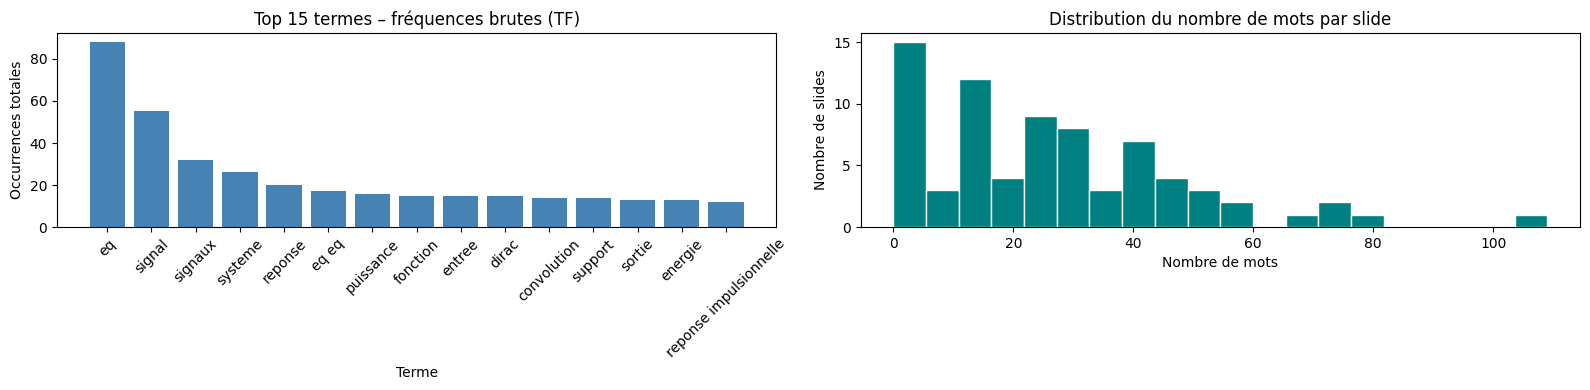

→ Les mots grammaticaux (stop words) ont été supprimés.
→ On observe que des mots grammaticaux dominent : c'est le problème du TF brut.
→ Longueur moyenne : 27 mots / slide


In [4]:
import matplotlib.pyplot as plt

# ── Top 15 termes les plus fréquents (comptes bruts) ─────────────────────
total_freq  = np.asarray(tf_counts.sum(axis=0)).flatten()
top15_idx   = total_freq.argsort()[::-1][:15]
top15_terms = vocab[top15_idx]
top15_freq  = total_freq[top15_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Graphe 1 : fréquences brutes TF
axes[0].bar(top15_terms, top15_freq, color="steelblue")
axes[0].set_title("Top 15 termes – fréquences brutes (TF)")
axes[0].set_xlabel("Terme")
axes[0].set_ylabel("Occurrences totales")
axes[0].tick_params(axis="x", rotation=45)

# Graphe 2 : distribution de la longueur des slides (nb de mots)
lengths = [len((s.get("slide_content") or "").split()) for s in slides]
axes[1].hist(lengths, bins=20, color="teal", edgecolor="white")
axes[1].set_title("Distribution du nombre de mots par slide")
axes[1].set_xlabel("Nombre de mots")
axes[1].set_ylabel("Nombre de slides")

plt.tight_layout()
plt.show()
print("→ Les mots grammaticaux (stop words) ont été supprimés.")
print("→ On observe que des mots grammaticaux dominent : c'est le problème du TF brut.")
print(f"→ Longueur moyenne : {sum(lengths)/len(lengths):.0f} mots / slide")


### Sauvegarde
On enregistre les résultats de la TF pour les utiliser ultérieurement:
- Le vectoriseur : permet de transformer une nouvelle question dans le même espace vectoriel que les slides en utilisant le vocabulaire appris.
- La matrice TF : le résultat de la transformation des slides, stocke les vecteurs pré-calculés de chaque slide, évitant de recalculer les fréquences documentaires à chaque utilisation de l’assistant.

In [5]:
import joblib
from scipy.sparse import save_npz

# On sauvegarde les comptes bruts (tf_counts) pour reconstruire tf_matrix si besoin
joblib.dump(tf_vectorizer, "../data/3-numerical/tf_vectorizer.pkl")
save_npz("../data/3-numerical/tf_matrix.npz", tf_counts)
print("TF vectorizer et matrice de comptes sauvegardés.")


TF vectorizer et matrice de comptes sauvegardés.


## TF-IDF

### Implémentation

La méthode **TF-IDF** (*Term Frequency–Inverse Document Frequency*) est une amélioration de la fréquence de terme (**TF**) qui intègre un facteur mesurant la rareté d’un mot dans l’ensemble des documents (**IDF**).

L’IDF mesure à quel point un mot est rare dans le corpus :

$$
IDF(w) = \log\left(\frac{N}{df(w)}\right) + 1
$$

où :
- N est le nombre total de documents  
- df(w) est le nombre de documents contenant le mot \(w\)

Le score TF-IDF est ensuite calculé par :

$$
TF\text{-}IDF(w, d) = TF(w, d) \times IDF(w)
$$

Les mots qui apparaissent fréquemment dans un document (ou slide) mais rarement dans l’ensemble des documents auront un score TF-IDF élevé.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Vectoriseur TF-IDF ────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(# Création du vectoriseur TF-IDF (fréquence + rareté des mots)
    analyzer="word",
    ngram_range=(1, 2),        # unigrammes + bigrammes (cohérent avec TF)
    min_df=2,                  # ignore les termes trop rares (cohérent avec TF)
    max_df=0.85,               # ignore les termes omniprésents
    sublinear_tf=True,         # log(1+TF) → atténue l'impact des répétitions
    strip_accents="unicode",   # Supprime les accents pour uniformiser le texte (é → e, etc.)
    stop_words=STOP_WORDS_FR,  # stop words français
    token_pattern=r"\b[a-zA-ZÀ-ÿ]{2,}\b",
    norm="l2",                 # normalisation L2 (cosinus-ready)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Dimensions TF-IDF : {tfidf_matrix.shape}")
print(f"Sparsité           : {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.1%}")

# ── Top 5 termes TF-IDF les plus discriminants par slide ─────────────────
print("\nTop 5 termes TF-IDF par slide :")
for i, label in enumerate(labels):
    row  = tfidf_matrix[i].toarray().flatten()
    top5 = row.argsort()[::-1][:5]
    terms = [(feature_names[j], round(row[j], 3)) for j in top5 if row[j] > 0]
    print(f"  {label[:45]:<45} → {terms}")


Dimensions TF-IDF : (75, 273)
Sparsité           : 95.4%

Top 5 termes TF-IDF par slide :
  Slide 2 – Les différentes classes de signaux  → [('classification', np.float64(0.6)), ('deterministes', np.float64(0.354)), ('continus', np.float64(0.354)), ('aleatoires', np.float64(0.354)), ('variables', np.float64(0.354))]
  Slide 3 – Classification en fonction du nombr → []
  Slide 4 – Signaux réels / complexes           → [('complexe', np.float64(0.577)), ('eq', np.float64(0.437)), ('reelle', np.float64(0.275)), ('reel eq', np.float64(0.275)), ('signal reel', np.float64(0.256))]
  Slide 5 – Signaux déterministes / aléatoires  → [('periodiques', np.float64(0.371)), ('transitoires', np.float64(0.358)), ('signaux', np.float64(0.318)), ('fonction', np.float64(0.24)), ('peut etre', np.float64(0.211))]
  Slide 6 – Signaux déterministes / aléatoires  → [('proprietes', np.float64(0.486)), ('bruit', np.float64(0.308)), ('evolution', np.float64(0.308)), ('dit qu', np.float64(0.308)), ('aleatoires', n

### Démonstration

In [7]:
def search_tfidf(question, tfidf_vectorizer, tfidf_matrix, slides, top_k=3):
    """
    Encode la question avec le vectoriseur TF-IDF et retourne
    les `top_k` slides les plus similaires (similarité cosinus).
    La matrice est déjà normalisée L2 → produit scalaire = cosinus.
    """
    q_vec   = tfidf_vectorizer.transform([question.lower()])
    scores  = cosine_similarity(q_vec, tfidf_matrix).flatten()
    ranking = scores.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(ranking):
        content = slides[idx].get("slide_content") or ""
        results.append({
            "rank"    : rank + 1,
            "slide_id": slides[idx]["slide_id"],
            "section" : slides[idx]["section"],
            "score"   : round(float(scores[idx]), 4),
            "extrait" : content[:120] + ("..." if len(content) > 120 else ""),
        })
    return results

# Test
question = "Qu'est-ce qu'un signal périodique ?"
resultats = search_tfidf(question, tfidf_vectorizer, tfidf_matrix, slides)

print(f"Question : {question}\n")
for r in resultats:
    print(f"  #{r['rank']} | Slide {r['slide_id']} | score={r['score']} | {r['section']}")
    print(f"       {r['extrait']}")
    print()


Question : Qu'est-ce qu'un signal périodique ?

  #1 | Slide 20 | score=0.4027 | Classification énergétique
       Cas des signaux périodiques
On a déjà vu qu’un signal périodique se répliquait une infinité de fois, il est donc nécessa...

  #2 | Slide 19 | score=0.3436 | Classification énergétique
       Propriétés d’un signal périodique:
Un signal périodique continu a nécessairement un support temporel non borné.
Démonstr...

  #3 | Slide 32 | score=0.272 | Quelques signaux élémentaires
       Signal rectangulaire
fenêtrage : si on prend un signal quelconque [EQ: 𝑥(𝑡) ]et qu’on le multiplie par un signal porte, ...



### Sauvegarde
On enregistre les résultats de la TF-IDF pour les utiliser ultérieurement. Le vectoriseur et la matrice TF-IDF sont de même rôle que la méthode de TF.

In [8]:
from scipy.sparse import save_npz

joblib.dump(tfidf_vectorizer, "../data/3-numerical/tfidf_vectorizer.pkl")
save_npz("../data/3-numerical/tfidf_matrix.npz", tfidf_matrix)
print("Vectoriseur TF-IDF sauvegardé → data/3-numerical/tfidf_vectorizer.pkl")
print("Matrice TF-IDF sauvegardée   → data/3-numerical/tfidf_matrix.npz")


Vectoriseur TF-IDF sauvegardé → data/3-numerical/tfidf_vectorizer.pkl
Matrice TF-IDF sauvegardée   → data/3-numerical/tfidf_matrix.npz


## Embeddings
Les embeddings(ou intégrations) sont des représentations de valeurs ou d'objets (dans notre cas du texte), conçues pour être utilisées par des modèles d'apprentissage automatique et des algorithmes de recherche sémantique. Elles convertissent ces objets dans une formule mathématique en fonction des facteurs ou des caractéristiques que chacun d'entre eux peut ou ne peut pas avoir, et des catégories auxquelles ils appartiennent. Concrètement, les embeddings permettent aux modèles d'apprentissage automatique de **trouver des objets similaires**.  

### Implémentation
Ce code construit pour chaque slide un texte enrichi en concaténant sa section, son contenu et ses notions, puis le préfixe par `passage:` comme requis par le modèle E5.

In [9]:
# Construction des textes enrichis pour chaque slide
texts = []
for slide in slides:
    section = slide.get("section") or ""
    content = slide.get("slide_content") or ""
    notions = " ".join(slide.get("notions") or [])
    # Texte enrchi
    enriched = f"Section : {section}\nContenu : {content}\nNotions : {notions}".strip()
    texts.append(f"passage: {enriched}")   # préfixe requis par le modèle E5

# Vérification
print(f"{len(texts)} textes construits.")
print("\nExemple (Slide 1) :")
print(texts[0][:300], "...")


75 textes construits.

Exemple (Slide 1) :
passage: Section : Les différentes classes de signaux
Contenu : Différents critères de classification :
Nombre de variables ;
Signaux réels / complexes ;
Déterministes / aléatoires ;
Continus / discrets ;
Classification énergétique.
Notions : Nombre Continus discrets ...


On charge le modèle multilingue `intfloat/multilingual-e5-base` et calcule les embeddings normalisés de tous les slides.

In [10]:
# 2. Chargement du modèle E5 multilingue
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"  # évite les warnings HuggingFace

from sentence_transformers import SentenceTransformer

# Chargement du modèle E5 multilingue
model = SentenceTransformer("intfloat/multilingual-e5-base")

# Calcul des embeddings (normalisés → produit scalaire = similarité cosinus)
print("Calcul des embeddings en cours...")
slide_embeddings = model.encode(
    texts,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=32,
)
# 3. Calcul des embeddings des slides (normalisés)
print(f"\nDimension des embeddings : {slide_embeddings.shape}")
print("Calcul terminé !")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calcul des embeddings en cours...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]


Dimension des embeddings : (75, 768)
Calcul terminé !


### Démonstration

In [11]:
def search_semantic(question, model, slide_embeddings, slides, top_k=3):
    """
    Encode la question avec le modèle E5 (préfixe "query:") et retourne
    les `top_k` slides les plus proches par produit scalaire
    (équivalent cosinus car les vecteurs sont normalisés).
    """
    q_emb   = model.encode([f"query: {question}"], normalize_embeddings=True)
    scores  = np.dot(slide_embeddings, q_emb.T).flatten()
    ranking = scores.argsort()[::-1][:top_k]
    results = []
    for rank, idx in enumerate(ranking):
        content = slides[idx].get("slide_content") or ""
        results.append({
            "rank"    : rank + 1,
            "slide_id": slides[idx]["slide_id"],
            "section" : slides[idx]["section"],
            "score"   : round(float(scores[idx]), 4),
            "extrait" : content[:120] + ("..." if len(content) > 120 else ""),
        })
    return results

# Test
question = "Comment représenter un signal dans le domaine fréquentiel ?"
resultats = search_semantic(question, model, slide_embeddings, slides)

print(f"Question : {question}\n")
for r in resultats:
    print(f"  #{r['rank']} | Slide {r['slide_id']} | score={r['score']} | {r['section']}")
    print(f"       {r['extrait']}")
    print()


Question : Comment représenter un signal dans le domaine fréquentiel ?

  #1 | Slide 44 | score=0.8397 | Remarques
       Sur le plan théorique, un signal est représenté par une fonction réelle ou complexe qui permet son étude de façon plus a...

  #2 | Slide 42 | score=0.8394 | Conclusion
       Etant donné un signal, on sait maintenant le caractériser de la façon suivante:
◮ Continu / Discret ?
◮ Support temporel...

  #3 | Slide 24 | score=0.8393 | Propriétés d’un signal
       Parité
Tout signal réel [EQ: 𝑥(𝑡) ]quelconque peut s’écrire sous forme de la  somme de deux signaux : un signal pair et ...



### Sauvegarde
Après réussir à représenter le cours numériquement, on sauvegarde les résultats consistants aux :
- embeddings des slides(format binaire)
- des métadonnées sur les slides: slide id, section et slide content (format json)

In [12]:
# Sauvegarde des embeddings
np.save("../data/3-numerical/slide_embeddings.npy", slide_embeddings)
print("Embeddings sauvegardés dans data/3-numerical/slide_embeddings.npy")

# Sauvegarde des métadonnées (avec chap_id et chap_name pour identifier le chapitre)
slides_metadata = []
for slide in slides:
    slides_metadata.append({
        "chap_id"      : slide.get("chap_id"),
        "chap_name"    : slide.get("chap_name"),
        "slide_id"     : slide.get("slide_id"),
        "section"      : slide.get("section"),
        "slide_content": slide.get("slide_content")
    })

with open("../data/3-numerical/slides_metadata.json", "w", encoding="utf-8") as f:
    json.dump(slides_metadata, f, indent=2, ensure_ascii=False)
print("Métadonnées sauvegardées dans data/3-numerical/slides_metadata.json")


Embeddings sauvegardés dans data/3-numerical/slide_embeddings.npy
Métadonnées sauvegardées dans data/3-numerical/slides_metadata.json


# Comparaison entre les méthodes de représentation numérique

On compare les scores de similarité obtenus par TF-IDF et Embeddings sur un ensemble de questions de test.

Question                                                |        TF top1         |      TF-IDF top1       |     Embedding top1    
-----------------------------------------------------------------------------------------------------------------------------
Qu'est-ce qu'un signal périodique ?                     | Slide 19 (0.4364)      | Slide 20 (0.4027)      | Slide 19 (0.8738)     
Comment calculer la transformée de Fourier ?            | Slide 25 (0.4472)      | Slide 25 (0.4639)      | Slide 30 (0.839)      
Définition de puissance moyenne                         | Slide 16 (0.8066)      | Slide 16 (0.6399)      | Slide 16 (0.8712)     
Qu'est ce qu'un signal expérimental ?                   | Slide 32 (0.4472)      | Slide 32 (0.3532)      | Slide 43 (0.8867)     
Quels sont les critères de classification des signaux ? | Slide 2 (0.6708)       | Slide 2 (0.6215)       | Slide 2 (0.8807)      


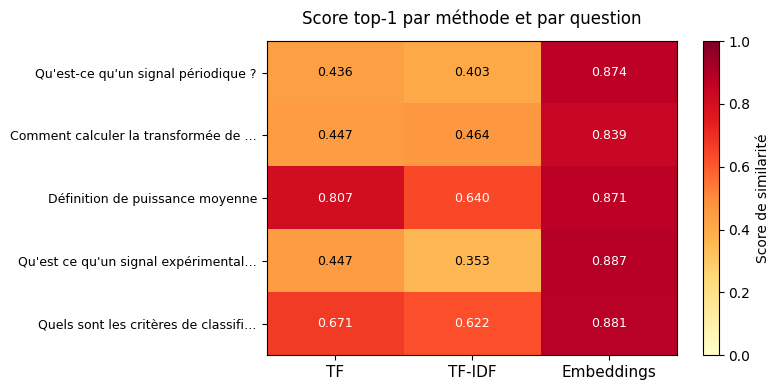


→ Les embeddings gèrent mieux les questions formulées différemment du texte du cours.
→ TF-IDF pénalise les mots trop fréquents grâce à l'IDF.
→ TF (normalisé L1) est plus sensible aux coïncidences lexicales exactes.


In [13]:
TEST_QUESTIONS = [
    "Qu'est-ce qu'un signal périodique ?",
    "Comment calculer la transformée de Fourier ?",
    "Définition de puissance moyenne",
    "Qu'est ce qu'un signal expérimental ?",
    "Quels sont les critères de classification des signaux ?",
]

# ── Tableau texte ─────────────────────────────────────────────────────────
print(f"{'Question':<55} | {'TF top1':^22} | {'TF-IDF top1':^22} | {'Embedding top1':^22}")
print("-" * 125)

rows = []
for q in TEST_QUESTIONS:
    tf_top    = search_tf(q, tf_vectorizer, tf_matrix, slides, top_k=1)[0]
    tfidf_top = search_tfidf(q, tfidf_vectorizer, tfidf_matrix, slides, top_k=1)[0]
    emb_top   = search_semantic(q, model, slide_embeddings, slides, top_k=1)[0]

    tf_str    = f"Slide {tf_top['slide_id']} ({tf_top['score']})"
    tfidf_str = f"Slide {tfidf_top['slide_id']} ({tfidf_top['score']})"
    emb_str   = f"Slide {emb_top['slide_id']} ({emb_top['score']})"
    rows.append((q, tf_top['score'], tfidf_top['score'], emb_top['score']))

    print(f"{q:<55} | {tf_str:<22} | {tfidf_str:<22} | {emb_str:<22}")

# ── Heatmap des scores ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

questions_short = [q[:35] + "…" if len(q) > 35 else q for q, *_ in rows]
scores_matrix   = np.array([[r[1], r[2], r[3]] for r in rows])
methods         = ["TF", "TF-IDF", "Embeddings"]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(scores_matrix, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(3))
ax.set_xticklabels(methods, fontsize=11)
ax.set_yticks(range(len(questions_short)))
ax.set_yticklabels(questions_short, fontsize=9)
ax.set_title("Score top-1 par méthode et par question", fontsize=12, pad=12)

for i in range(len(rows)):
    for j in range(3):
        val = scores_matrix[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=9, color="black" if val < 0.6 else "white")

plt.colorbar(im, ax=ax, label="Score de similarité")
plt.tight_layout()
plt.show()

print("\n→ Les embeddings gèrent mieux les questions formulées différemment du texte du cours.")
print("→ TF-IDF pénalise les mots trop fréquents grâce à l'IDF.")
print("→ TF (normalisé L1) est plus sensible aux coïncidences lexicales exactes.")
